<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [14]:
taxi = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")

import pandas as pd

taxi[['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']].describe()

,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [15]:
taxi.loc[taxi['trip_distance'].idxmax(), ['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']]

fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 8338, dtype: object

<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [24]:
meteorites = pd.read_csv("data/Meteorite_Landings.csv")

meteorites = meteorites.rename(columns={'mass (g)': 'mass'})

meteorites = meteorites.drop(columns=['reclat', 'reclong'], errors='ignore')

meteorites_sorted = meteorites.sort_values(by='mass', ascending=False)

print(meteorites_sorted.head())

                  name     id nametype      recclass        mass   fall  \
16392             Hoba  11890    Valid     Iron, IVB  60000000.0  Found   
5373         Cape York   5262    Valid   Iron, IIIAB  58200000.0  Found   
5365   Campo del Cielo   5247    Valid  Iron, IAB-MG  50000000.0  Found   
5370     Canyon Diablo   5257    Valid  Iron, IAB-MG  30000000.0  Found   
3455           Armanty   2335    Valid    Iron, IIIE  28000000.0  Found   

                         year             GeoLocation  
16392  01/01/1920 12:00:00 AM   (-19.58333, 17.91667)  
5373   01/01/1818 12:00:00 AM   (76.13333, -64.93333)  
5365   12/22/1575 12:00:00 AM  (-27.46667, -60.58333)  
5370   01/01/1891 12:00:00 AM     (35.05, -111.03333)  
3455   01/01/1898 12:00:00 AM            (47.0, 88.0)  


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [50]:
meteorites['year'] = meteorites['year'].astype(str).str.slice(6, 10)

# Convert to numeric
meteorites['year'] = pd.to_numeric(meteorites['year'], errors='coerce')

# Create pre_1970 column
meteorites['pre_1970'] = meteorites['year'] < 1970

# Set first column as index and sort
meteorites = meteorites.set_index(meteorites.columns[0]).sort_index()

# Get rows 10036-10040 (only those that exist)
ids = [i for i in range(10036, 10041) if i in meteorites.index]
subset = meteorites.loc[ids] if ids else pd.DataFrame()

print(subset)

Empty DataFrame
Columns: []
Index: []


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [43]:
future_meteorites = meteorites[meteorites['year'] > 2025]
print(future_meteorites)


Empty DataFrame
Columns: [name, nametype, recclass, mass, fall, year, GeoLocation, pre_1970]
Index: []


There's a meteorite that was reportedly found in the future:

In [ ]:
# Your code here


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [51]:
taxi['tpep_dropoff_datetime'] = pd.to_datetime(taxi['tpep_dropoff_datetime'])

# Set dropoff time as index
taxi = taxi.set_index('tpep_dropoff_datetime')

# Resample to hourly frequency and calculate total trip_distance, fare_amount, tolls_amount, and tip_amount
hourly_data = taxi[['trip_distance', 'fare_amount', 'tolls_amount', 'tip_amount']].resample('H').sum()

# Find the 5 hours with the most tips
top_5_hours = hourly_data.nlargest(5, 'tip_amount')
print(top_5_hours)

                       trip_distance  fare_amount  tolls_amount  tip_amount
tpep_dropoff_datetime                                                      
2019-10-23 16:00:00         10676.95     67797.76        699.04    12228.64
2019-10-23 17:00:00         16052.83     70131.91       4044.04    12044.03
2019-10-23 18:00:00          3104.56     11565.56       1454.67     1907.64
2019-10-23 15:00:00            14.34       213.50          0.00       51.75
2019-10-23 19:00:00            98.59       268.00         24.48       25.74


/tmp/ipykernel_3545/1739330909.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = taxi[['trip_distance', 'fare_amount', 'tolls_amount', 'tip_amount']].resample('H').sum()


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

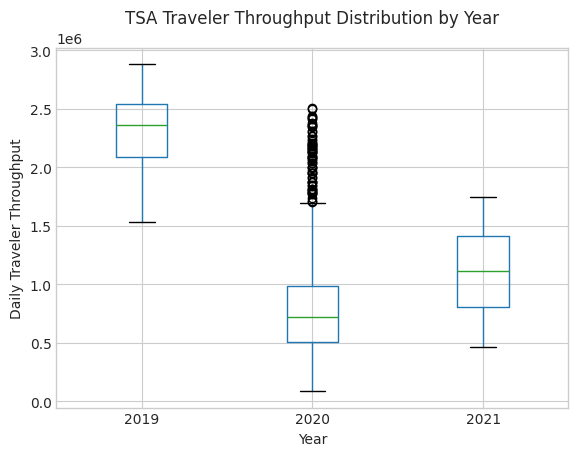

In [ ]:
tsa = pd.read_csv("data/tsa_melted_holiday_travel.csv")

tsa.boxplot(column='travelers', by='year')

plt.suptitle('TSA Traveler Throughput Distribution by Year')

plt.title('')

plt.xlabel('Year')
plt.ylabel('Daily Traveler Throughput')

plt.show()

<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

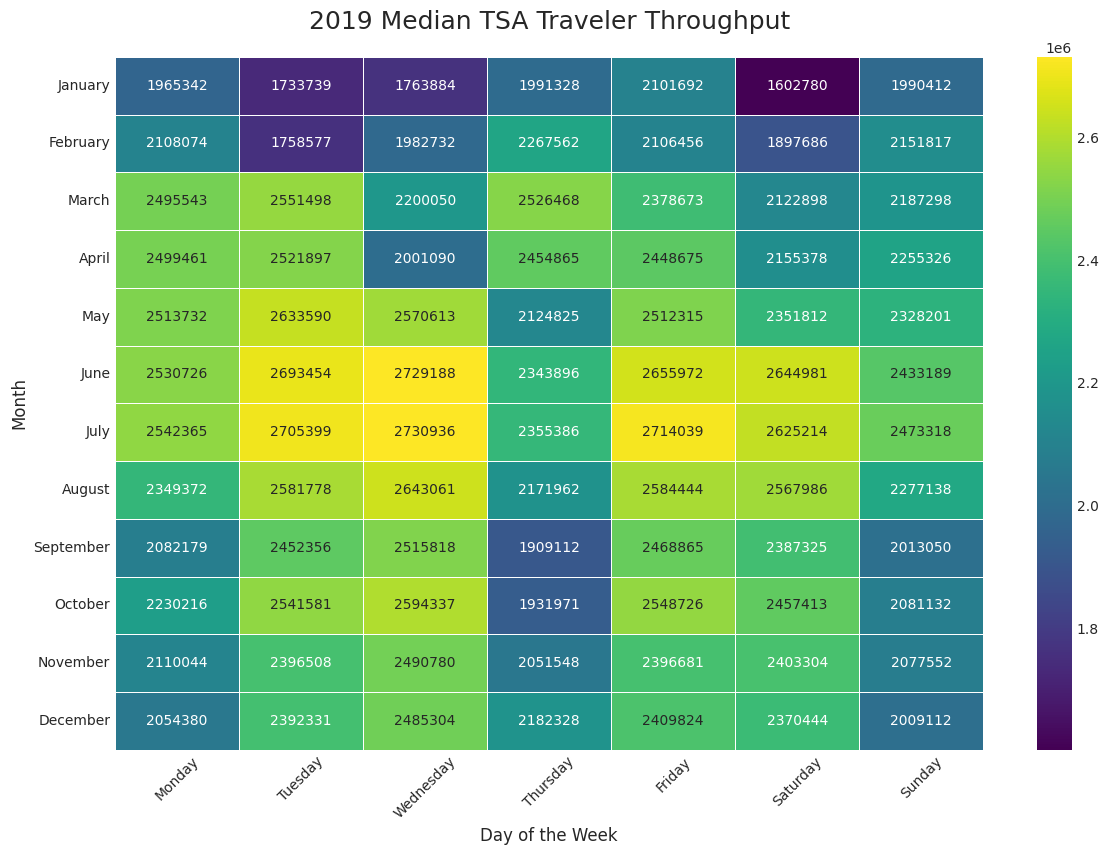

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and Prepare the Data
# Load the dataset
tsa = pd.read_csv("data/tsa_melted_holiday_travel.csv")

# Convert the 'date' column to a proper datetime object
tsa['date'] = pd.to_datetime(tsa['date'])

# Filter the data to include only the year 2019
tsa_2019 = tsa[tsa['date'].dt.year == 2019].copy()

# Extract the month and day of the week names into new columns
tsa_2019['month'] = tsa_2019['date'].dt.month_name()
tsa_2019['day_of_week'] = tsa_2019['date'].dt.day_name()


# 2. Create a Pivot Table
# This reshapes the data: months as rows, days as columns,
# and median traveler count as the values.
heatmap_data = tsa_2019.pivot_table(
    values='travelers',
    index='month',
    columns='day_of_week',
    aggfunc='median' # Calculate the median for each group
)

# 3. Order the Data Chronologically
# By default, pivot_table sorts alphabetically. We need to reorder it.
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
day_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Apply the correct ordering to the pivot table's index and columns
heatmap_data = heatmap_data.reindex(index=month_order, columns=day_order)


# 4. Generate the Heatmap
plt.figure(figsize=(14, 9)) # Create a figure with a custom size
sns.heatmap(
    heatmap_data,
    annot=True,         # Display the median values on the heatmap
    fmt=".0f",          # Format the numbers as integers
    cmap='viridis',     # Use the 'viridis' color scheme
    linewidths=.5       # Add thin lines between cells for clarity
)

# Customize titles and labels for a polished look
plt.title('2019 Median TSA Traveler Throughput', fontsize=18, pad=20)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.xticks(rotation=45) # Rotate day names for better readability

# Show the plot
plt.show()
